# **Dataset Description and Problem Statement**


>This dataset contains information about used cars, including features such as year, selling price, kilometers driven, fuel type, transmission, mileage, engine capacity, max power, torque, seats, ownership details, and brand.






> The objective of this project is to build a machine learning regression model that can predict the selling price of a used car based on its features.





> The dataset was preprocessed by handling missing values, converting data types, encoding categorical variables, and treating unrealistic values. Exploratory Data Analysis (EDA) was performed to study feature distributions, relationships, and outliers.




> Finally, regression models were trained and evaluated using metrics such as MAE, RMSE, and R² Score to measure prediction performance.





In [1311]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler,LabelEncoder,OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier
)
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

import matplotlib.pyplot as plt
import seaborn as sns



In [1312]:
df=pd.read_csv("cardetails.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [1313]:
df.isna().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


#NULL VALUES


> Mulitple null values were found in the cols:

* Mileage
* Engine
* Max Power
* Torque
* Seats








In [1314]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8123,False
8124,False
8125,False
8126,True


In [1315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [1316]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [1317]:
df.drop_duplicates()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [1318]:
df.shape

(8128, 13)

In [1319]:
df.isnull().sum().sort_values(ascending=False)

,0
torque,222
seats,221
engine,221
mileage,221
max_power,215
fuel,0
km_driven,0
selling_price,0
year,0
name,0


In [1320]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
torque,2.731299
seats,2.718996
engine,2.718996
mileage,2.718996
max_power,2.645177
fuel,0.000000
km_driven,0.000000
selling_price,0.000000
year,0.000000
name,0.000000


In [1321]:
# Remove units and convert to numeric

# mileage -> "19.7 kmpl" -> 19.7
df['mileage'] = df['mileage'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# engine -> "1248 CC" -> 1248
df['engine'] = df['engine'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# max_power -> "88.5 bhp" -> 88.5
df['max_power'] = df['max_power'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# torque -> take first numeric value from strings like "200Nm@1750rpm"
df['torque'] = df['torque'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

In [1322]:
df[df['max_power']==0]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
575,Maruti Alto K10 LXI,2011,204999,97500,Petrol,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
576,Maruti Alto K10 LXI,2011,204999,97500,Petrol,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
1442,Maruti Swift Dzire VDI Optional,2017,589000,41232,Diesel,Dealer,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
1443,Maruti Swift Dzire VDI Optional,2017,589000,41232,Diesel,Dealer,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
2549,Tata Indica Vista Quadrajet LS,2012,240000,70000,Diesel,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
2550,Tata Indica Vista Quadrajet LS,2012,240000,70000,Diesel,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN


In [1323]:
# Verify conversion
df[['mileage', 'engine', 'max_power', 'torque']].head()

,mileage,engine,max_power,torque
0,23.40,1248.0,74.00,190.0
1,21.14,1498.0,103.52,250.0
2,17.70,1497.0,78.00,12.7
3,23.00,1396.0,90.00,22.4
4,16.10,1298.0,88.20,11.5


In [1324]:
# Check null percentages again
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
torque,2.731299
seats,2.718996
engine,2.718996
mileage,2.718996
max_power,2.657480
fuel,0.000000
km_driven,0.000000
selling_price,0.000000
year,0.000000
name,0.000000


In [1325]:
# Numerical columns
num_cols = ['torque', 'seats', 'engine', 'mileage', 'max_power']

# Group-wise median filling using car name
for col in num_cols:
    df[col] = df.groupby('name')[col] \
                .transform(lambda x: x.fillna(x.median()))

In [1326]:
# Fallback: fill any remaining nulls with overall median
#for col in num_cols:
    #df[col].fillna(df[col].median())



> Filled the NaN values of certain specific car names with group by car name, This allowed for the completion of around 50 rows with 160 yet missing because the whole group by rows is missing



In [1327]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,160
engine,160


In [1328]:
print(df[df['name']=='Maruti Swift 1.3 VXi'])

                      name  year  selling_price  km_driven    fuel  \
13    Maruti Swift 1.3 VXi  2007         200000      80000  Petrol   
228   Maruti Swift 1.3 VXi  2008         130000     120000  Petrol   
306   Maruti Swift 1.3 VXi  2010         215000      70000  Petrol   
743   Maruti Swift 1.3 VXi  2006         140000      65000  Petrol   
1331  Maruti Swift 1.3 VXi  2008         240000      60000  Petrol   
1785  Maruti Swift 1.3 VXi  2007         150000      70000  Petrol   
4731  Maruti Swift 1.3 VXi  2009         220000      25000  Petrol   
5742  Maruti Swift 1.3 VXi  2007         150000      80000  Petrol   
5817  Maruti Swift 1.3 VXi  2009         180000      50000  Petrol   
6404  Maruti Swift 1.3 VXi  2008         200000      80000  Petrol   
7179  Maruti Swift 1.3 VXi  2010         175000      83000  Petrol   
7433  Maruti Swift 1.3 VXi  2009         198000      91000  Petrol   
7582  Maruti Swift 1.3 VXi  2006         215000      90000  Petrol   
8103  Maruti Swift 1

In [1329]:
# Create brand column from car name
df['brand'] = df['name'].str.split().str[0]

# Verify column exists
df[['name', 'brand']].head()
# Average torque for each brand with Diesel fuel type
avg_torque_diesel = (
    df[df['fuel'] == 'Diesel']
    .groupby('brand')['torque']
    .mean()
    .sort_values(ascending=False)
)

avg_torque_diesel

,torque
brand,
Jaguar,440.422535
Audi,424.857143
Mercedes-Benz,414.187500
BMW,407.214783
Land,391.333333
Volvo,378.484848
Isuzu,352.600000
Jeep,350.000000
Force,275.500000


In [1330]:
# Create brand column
df['brand'] = df['name'].str.split().str[0]

for col in ['torque','mileage', 'engine', 'max_power', 'seats']:

    # Fill using brand + fuel
    df[col] = df.groupby(['brand', 'fuel'])[col].transform(
        lambda x: x.fillna(x.median())
    )

In [1331]:
#df['torque'] = df.groupby(['brand', 'fuel'])['torque'].transform(
   # lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
#)

In [1332]:
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df[col] = df[col].fillna(df[col].median())

df['torque'] = df['torque'].fillna(df['torque'].mode()[0])



> Filled the null values of the rows who have only null in certain cols by taking the median of their brands instead of their name perfect medians

> This allowed for a more understandable filling of Null values that are meaningful





In [1333]:
df.isna().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [1334]:
print(df[df['name']=='Maruti Swift 1.3 VXi'])

                      name  year  selling_price  km_driven    fuel  \
13    Maruti Swift 1.3 VXi  2007         200000      80000  Petrol   
228   Maruti Swift 1.3 VXi  2008         130000     120000  Petrol   
306   Maruti Swift 1.3 VXi  2010         215000      70000  Petrol   
743   Maruti Swift 1.3 VXi  2006         140000      65000  Petrol   
1331  Maruti Swift 1.3 VXi  2008         240000      60000  Petrol   
1785  Maruti Swift 1.3 VXi  2007         150000      70000  Petrol   
4731  Maruti Swift 1.3 VXi  2009         220000      25000  Petrol   
5742  Maruti Swift 1.3 VXi  2007         150000      80000  Petrol   
5817  Maruti Swift 1.3 VXi  2009         180000      50000  Petrol   
6404  Maruti Swift 1.3 VXi  2008         200000      80000  Petrol   
7179  Maruti Swift 1.3 VXi  2010         175000      83000  Petrol   
7433  Maruti Swift 1.3 VXi  2009         198000      91000  Petrol   
7582  Maruti Swift 1.3 VXi  2006         215000      90000  Petrol   
8103  Maruti Swift 1

In [1335]:
# Treat 0 mileage as missing
df['mileage'] = df['mileage'].replace(0, np.nan)

# Fill missing mileage using median mileage of same car name
df['mileage'] = df.groupby('name')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

In [1336]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,17
engine,0


In [1337]:
# Replace impossible mileage values
df['mileage'] = df['mileage'].replace(0, np.nan)

# -----------------------------------
# 1. Fill using same car name
# -----------------------------------

df['mileage'] = df.groupby('name')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

# -----------------------------------
# 2. Fill remaining using same brand
# -----------------------------------

df['mileage'] = df.groupby('brand')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

# -----------------------------------
# 3. Final fallback (very few rows)
# -----------------------------------

df['mileage'] = df['mileage'].fillna(
    df['mileage'].median()
)

In [1338]:
# Replace impossible values
df['max_power'] = df['max_power'].replace(0, np.nan)

# -----------------------------------
# 1. Fill using same car name
# -----------------------------------

df['max_power'] = df.groupby('name')['max_power'].transform(
    lambda x: x.fillna(x.median())
)

# -----------------------------------
# 2. Fill remaining using same brand
# -----------------------------------

df['max_power'] = df.groupby('brand')['max_power'].transform(
    lambda x: x.fillna(x.median())
)

# -----------------------------------
# 3. Final fallback
# -----------------------------------

df['max_power'] = df['max_power'].fillna(
    df['max_power'].median()
)



> Converted min value of mileage of 0 to that brands median to have a better dataset



In [1339]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.465764,1455.231053,91.239657,167.724149,5.414370
std,4.044249,8.062534e+05,5.655055e+04,3.921548,501.456474,35.453174,96.482421,0.956183
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,4.800000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.000000,68.050000,101.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,154.900000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,102.000000,200.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,14.000000


# DATA CLEANING DONE
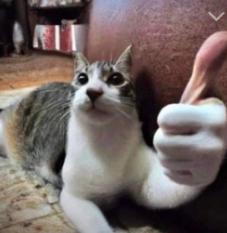

# EDA


In [1340]:
max(df['mileage'])

42.0

In [1341]:
current_year = 2026

df['car_age'] = current_year - df['year']
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.0,5.0,Maruti,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.0,5.0,Skoda,12
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7,5.0,Honda,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4,5.0,Hyundai,16
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5,5.0,Maruti,19




>Feature engineering is done here as we took car_age



In [1342]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,car_age
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.465764,1455.231053,91.239657,167.724149,5.414370,12.195989
std,4.044249,8.062534e+05,5.655055e+04,3.921548,501.456474,35.453174,96.482421,0.956183,4.044249
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,4.800000,2.000000,6.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.000000,68.050000,101.000000,5.000000,9.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,154.900000,5.000000,11.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,102.000000,200.000000,5.000000,15.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,14.000000,43.000000


In [1343]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns


# CHECKING NUMERICAL COLS UNIVARIATE

In [1344]:
df[numerical_cols].describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,car_age
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.465764,1455.231053,91.239657,167.724149,5.414370,12.195989
std,4.044249,8.062534e+05,5.655055e+04,3.921548,501.456474,35.453174,96.482421,0.956183,4.044249
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,4.800000,2.000000,6.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.000000,68.050000,101.000000,5.000000,9.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,154.900000,5.000000,11.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,102.000000,200.000000,5.000000,15.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,14.000000,43.000000


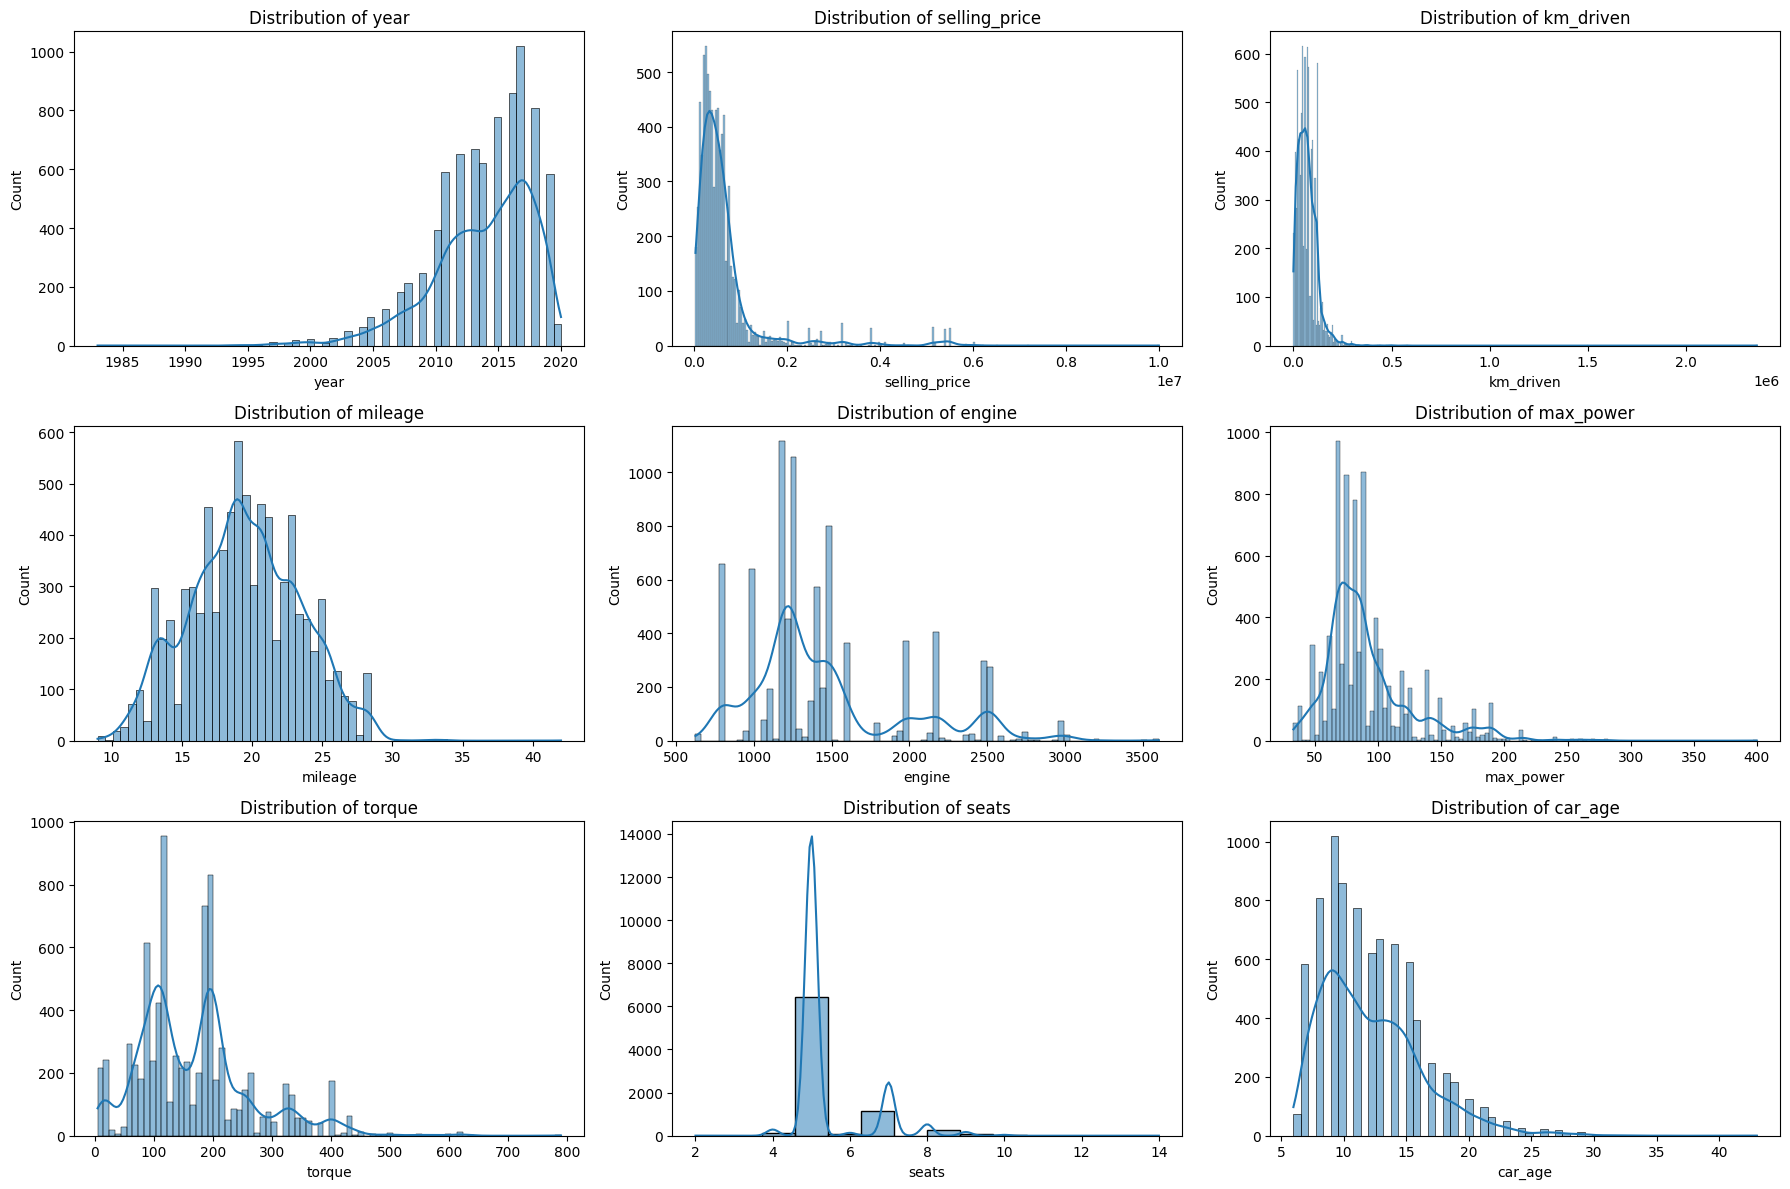

In [1345]:
import math
num_cols = len(numerical_cols)

# Define grid size
rows = math.ceil(num_cols / 3)
cols = 3

plt.figure(figsize=(18, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

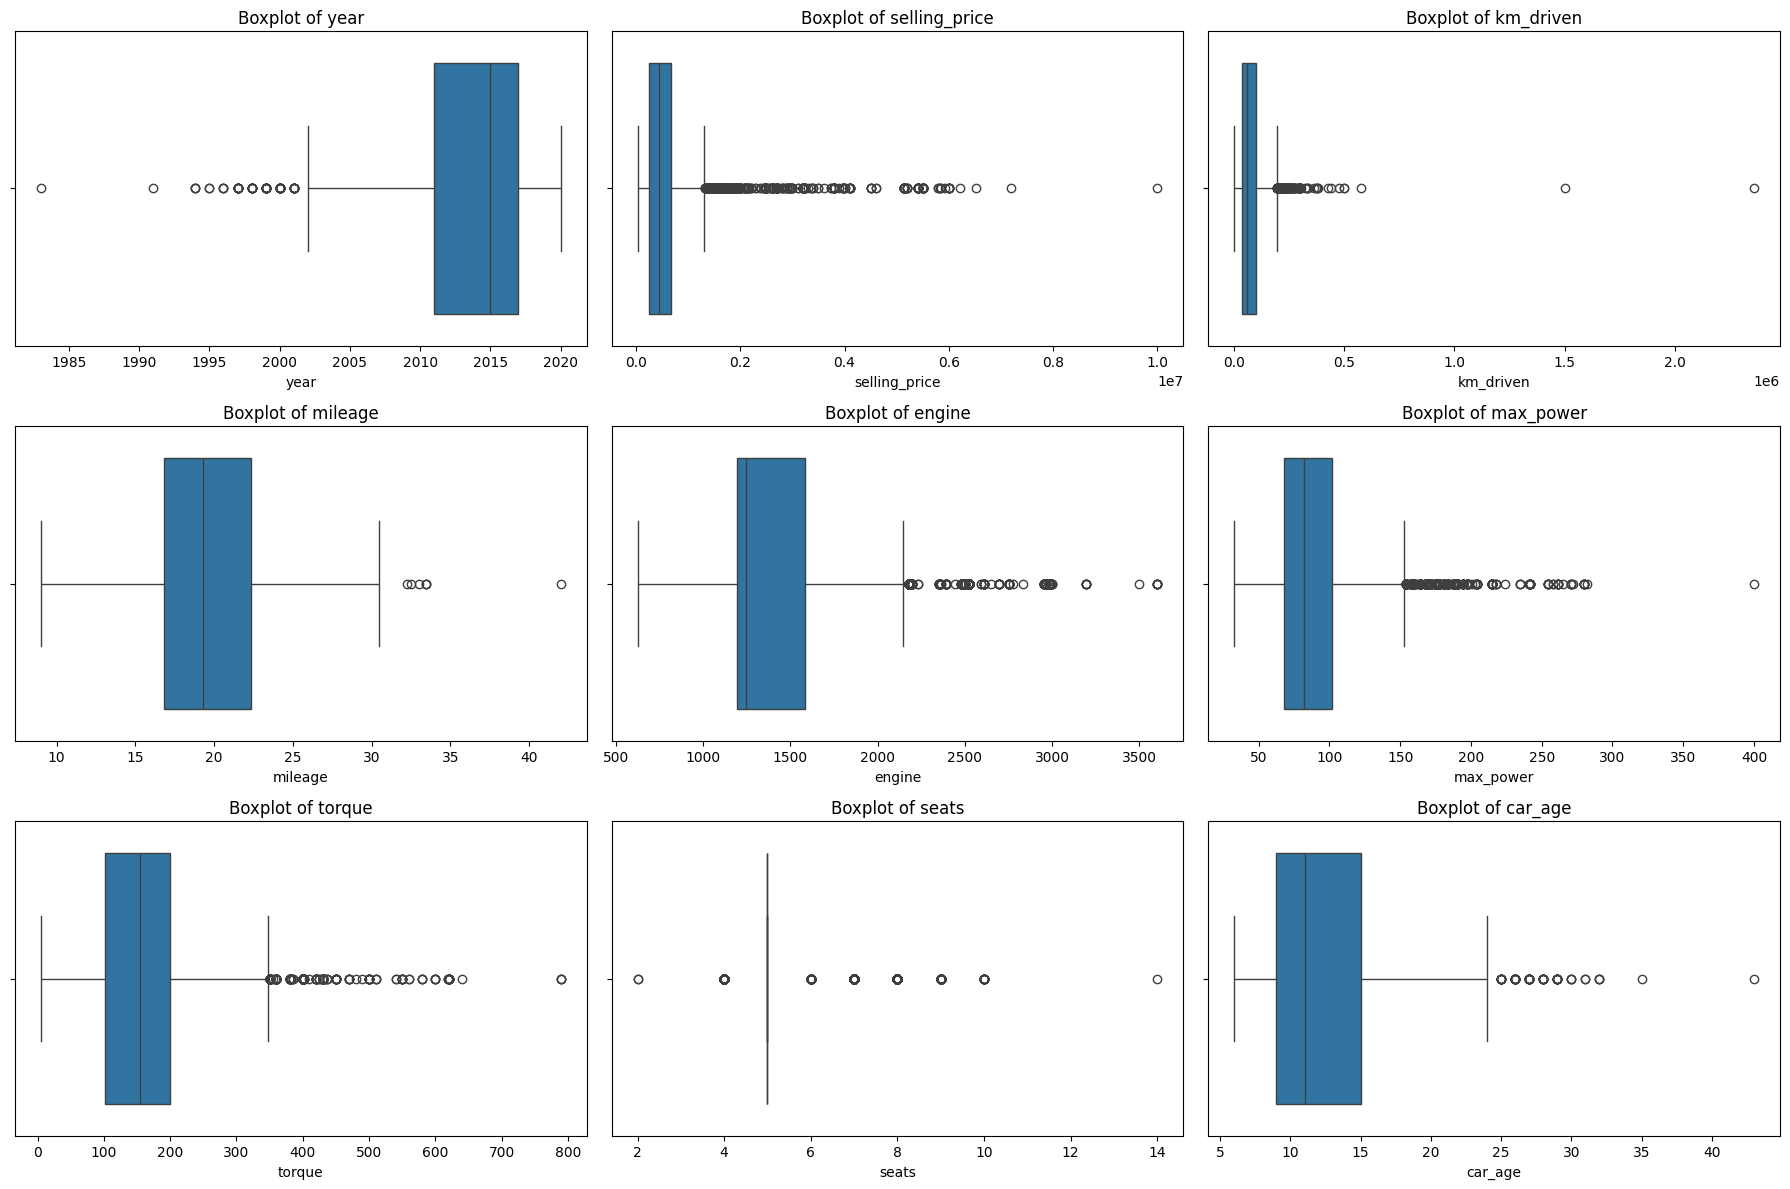

In [1346]:
plt.figure(figsize=(18, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [1347]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print(skewness)

km_driven        11.170910
selling_price     4.193533
seats             1.977017
max_power         1.661780
engine            1.148685
torque            1.074312
car_age           1.072293
mileage           0.071410
year             -1.072293
dtype: float64




> There is a moderate skew in mileage, year car age etc due to their outliers


> A Massive skew is observed in the KMs and the Selling price that was found to be huge with values of 11.17 and 4.193





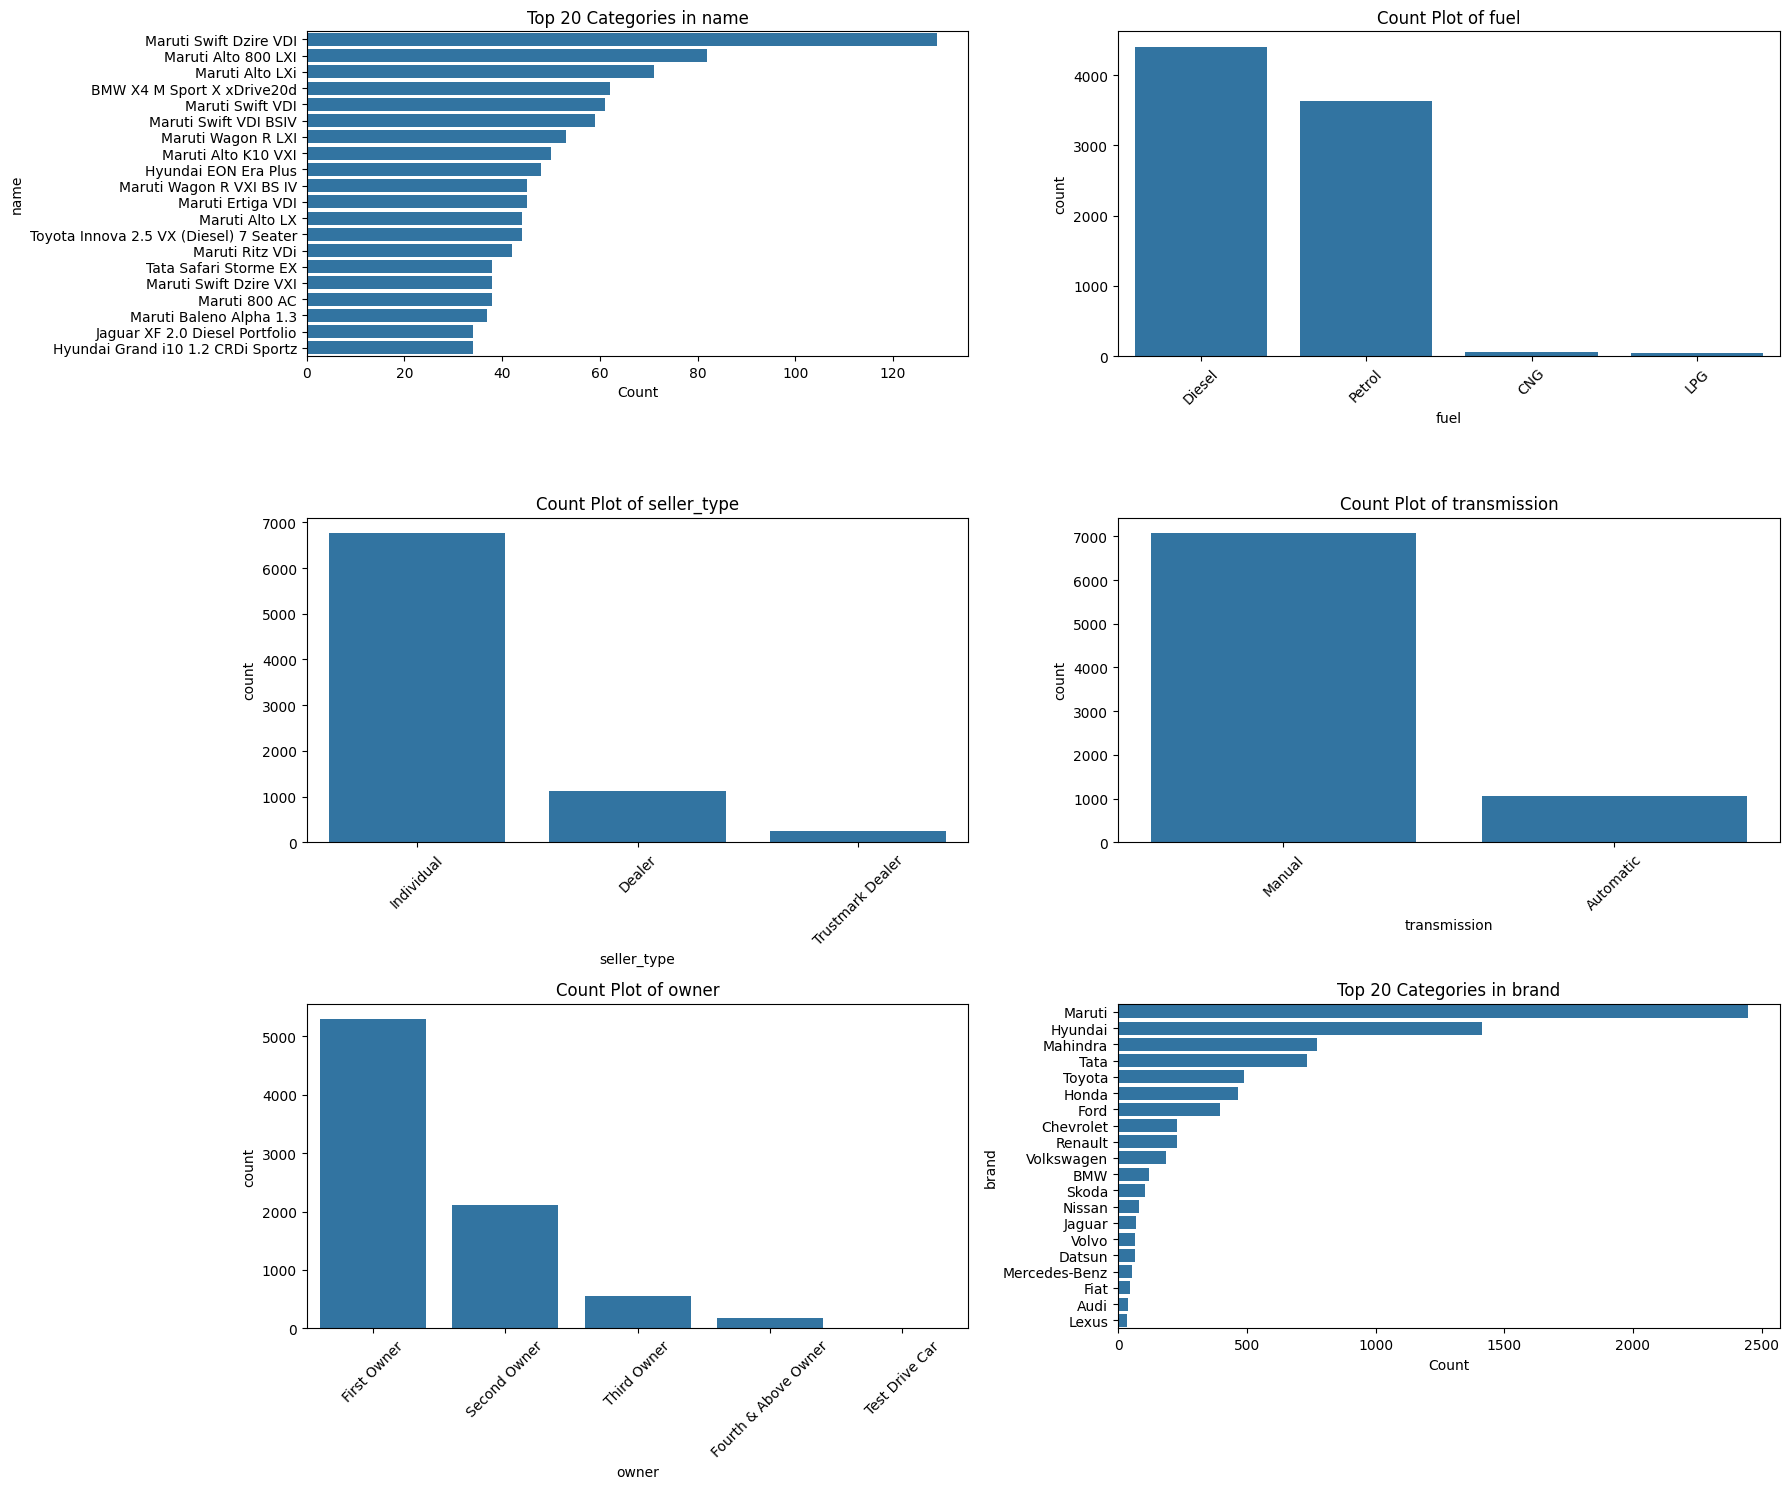

In [1348]:
# Count how many categorical columns will actually be plotted
num_plots = len(categorical_cols)

# Create subplot grid
cols = 2
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))

# Flatten axes for easy looping
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = axes[i]

    # High-cardinality columns
    if df[col].nunique() > 20:

        top_values = df[col].value_counts().head(20)

        sns.barplot(
            x=top_values.values,
            y=top_values.index,
            ax=ax
        )

        ax.set_title(f"Top 20 Categories in {col}")
        ax.set_xlabel("Count")
        ax.set_ylabel(col)

    # Normal categorical columns
    else:

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            ax=ax
        )

        ax.set_title(f"Count Plot of {col}")
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [1349]:
for col in categorical_cols:

    print(f"\nPercentage Distribution of {col}")
    print("-"*50)

    percentage = (
        df[col]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(percentage)


Percentage Distribution of name
--------------------------------------------------
name
Maruti Swift Dzire VDI              1.59
Maruti Alto 800 LXI                 1.01
Maruti Alto LXi                     0.87
BMW X4 M Sport X xDrive20d          0.76
Maruti Swift VDI                    0.75
                                    ... 
Maruti 800 DX BSII                  0.01
Ford Figo Aspire Titanium Diesel    0.01
Hyundai Verna CRDi 1.6 SX           0.01
Maruti Baleno Alpha Diesel          0.01
Tata New Safari Dicor VX 4X2        0.01
Name: proportion, Length: 2058, dtype: float64

Percentage Distribution of fuel
--------------------------------------------------
fuel
Diesel    54.16
Petrol    44.67
CNG        0.70
LPG        0.47
Name: proportion, dtype: float64

Percentage Distribution of seller_type
--------------------------------------------------
seller_type
Individual          83.24
Dealer              13.85
Trustmark Dealer     2.90
Name: proportion, dtype: float64

Percentage D



> There are several imbalances inside of the categorical cols


> Fuel is dominated by Petrol and diesel

> Individual seller dominates the sellers cols


> Manual transmission also dominates in transmission types with 87%


> There are more first owners than any other types and only 5 rows of test drive ones exists



> Maruti is the brand who holds a major share with 30%













In [1350]:
for col in categorical_cols:

    print(f"{col} : {df[col].nunique()} unique values")

name : 2058 unique values
fuel : 4 unique values
seller_type : 3 unique values
transmission : 2 unique values
owner : 5 unique values
brand : 32 unique values


In [1351]:
df.columns


Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'brand', 'car_age'],
      dtype='object')

#BIVARIATE ANALYSIS

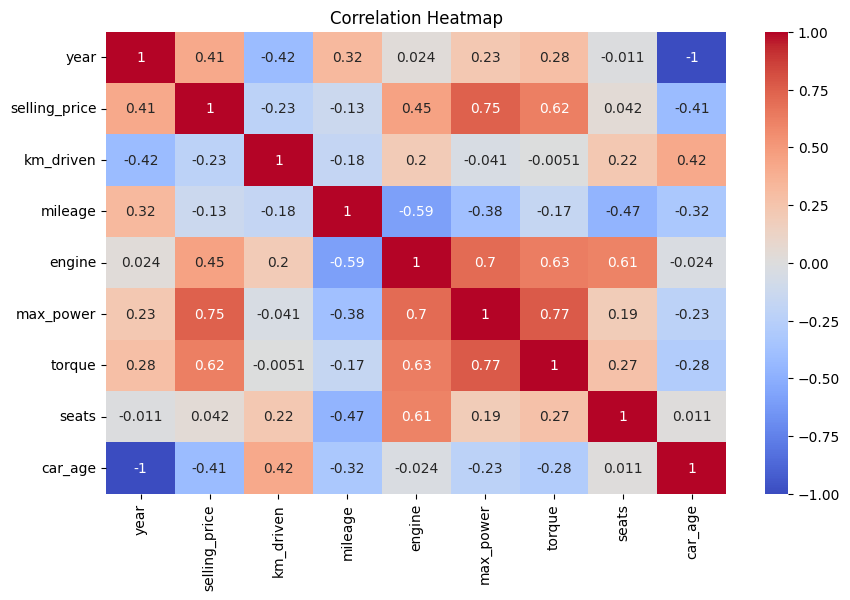

In [1352]:
plt.figure(figsize=(10,6))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

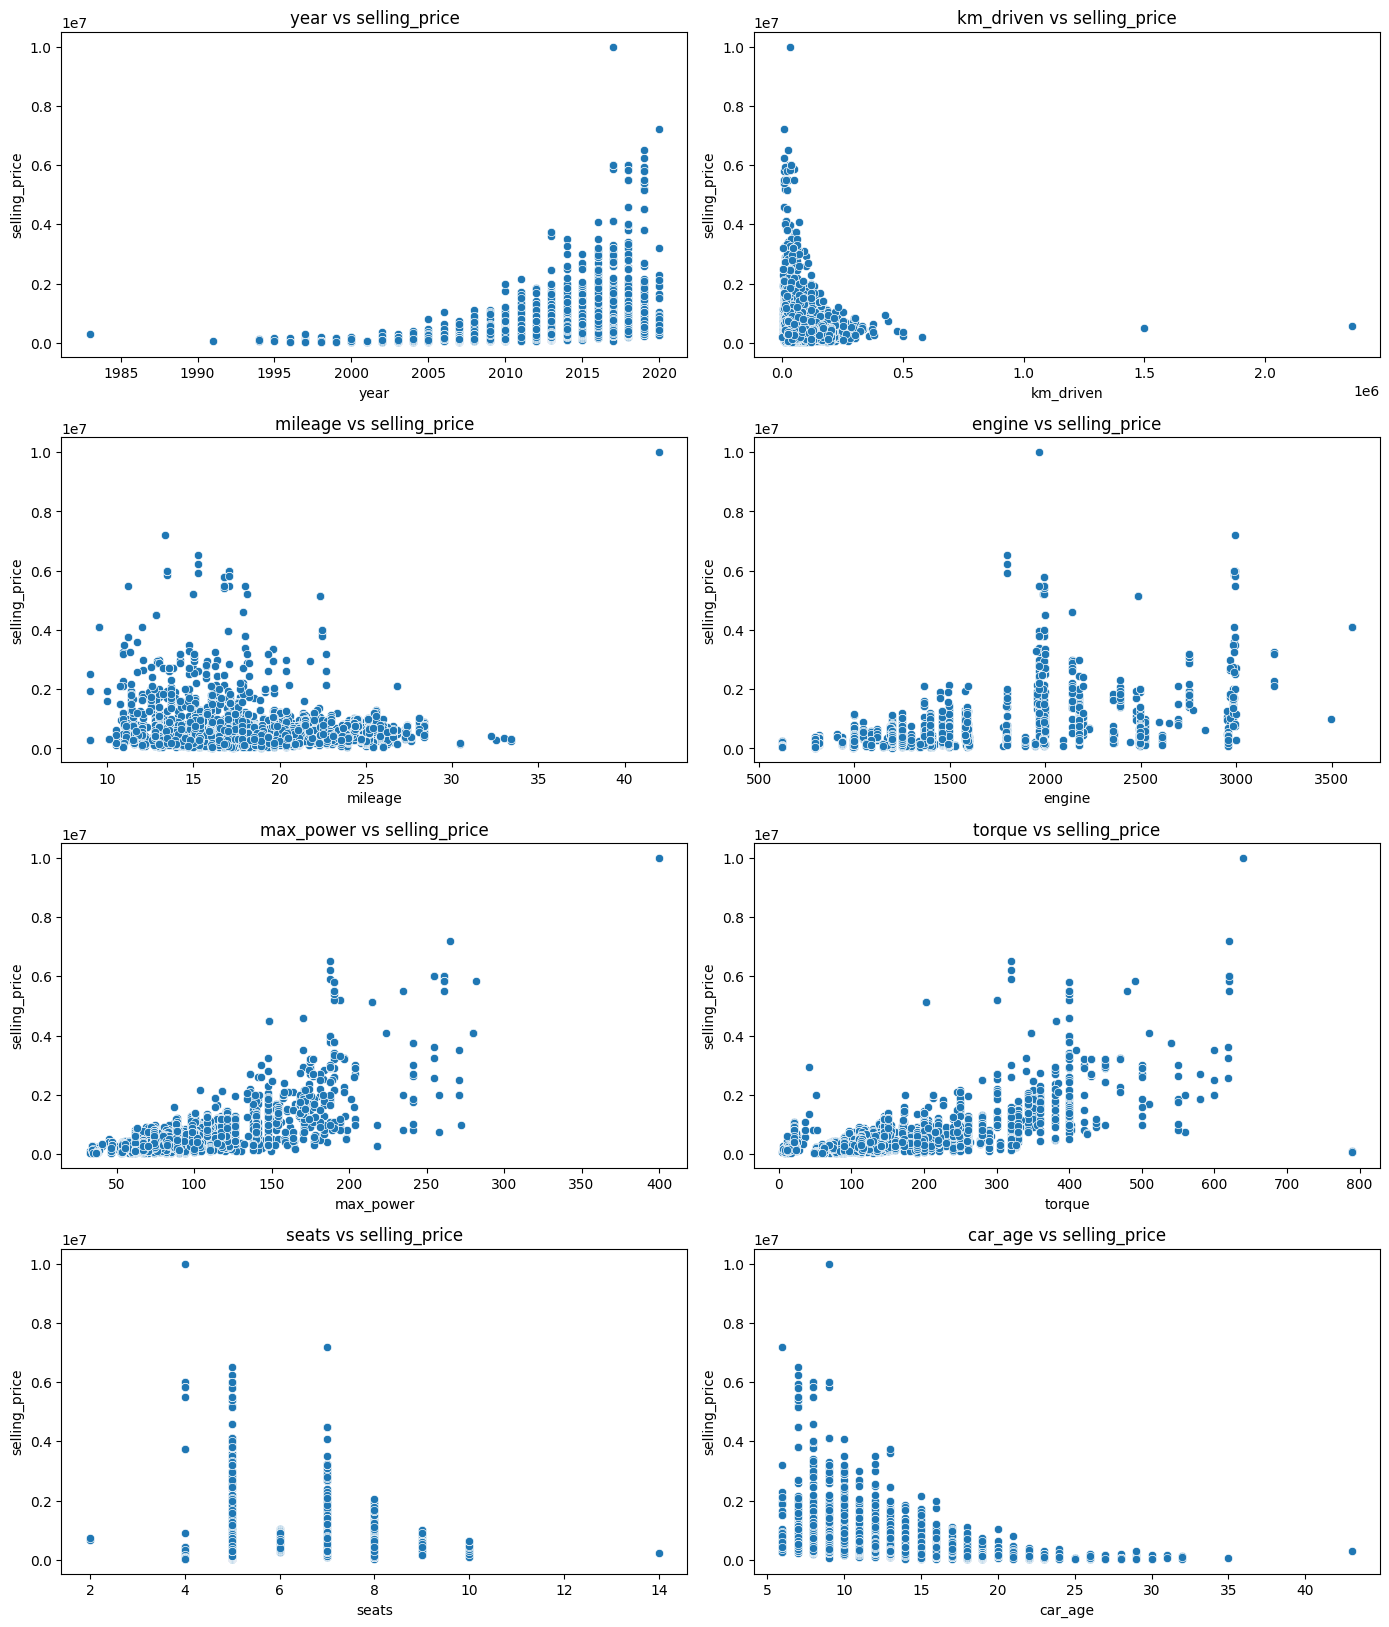

In [1353]:
target = 'selling_price'

features = [col for col in numerical_cols if col != target]

fig, axes = plt.subplots(len(features)//2 + 1, 2, figsize=(14,20))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.scatterplot(
        x=df[col],
        y=df[target],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs {target}')

# Remove extra plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

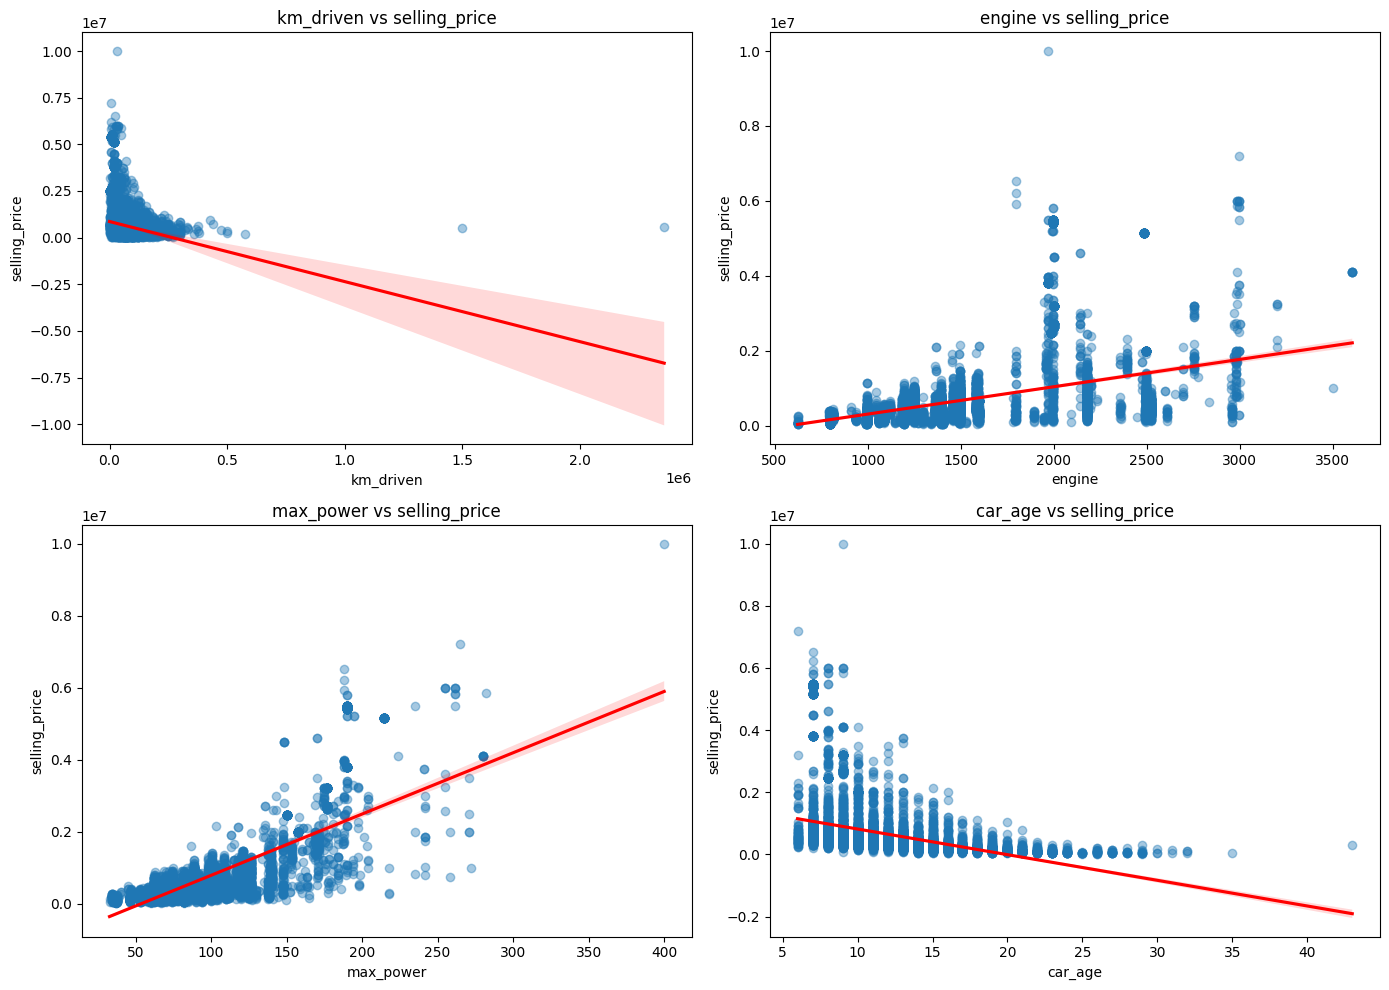

In [1354]:
important_cols = ['km_driven', 'engine', 'max_power', 'car_age']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, col in enumerate(important_cols):

    sns.regplot(
        x=df[col],
        y=df['selling_price'],
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs selling_price')

plt.tight_layout()

plt.show()

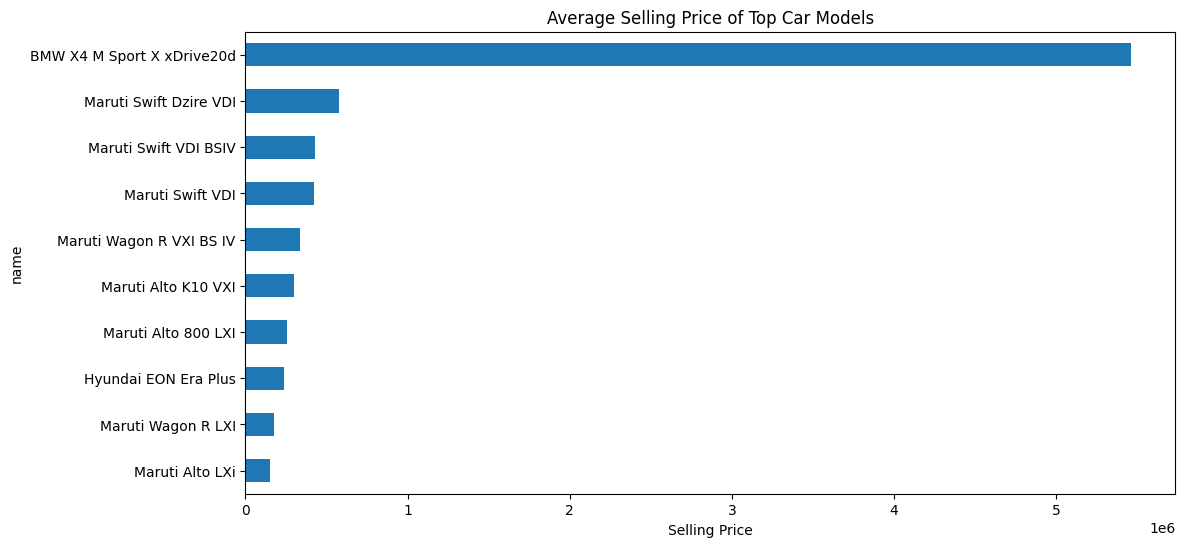

In [1355]:
top_names = df['name'].value_counts().head(10).index

avg_price = (
    df[df['name'].isin(top_names)]
    .groupby('name')['selling_price']
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

avg_price.plot(kind='barh')

plt.title('Average Selling Price of Top Car Models')

plt.xlabel('Selling Price')

plt.show()

In [1356]:
df['km_driven'].describe(percentiles=[0.95,0.99])

,km_driven
count,8.128000e+03
mean,6.981951e+04
std,5.655055e+04
min,1.000000e+00
50%,6.000000e+04
95%,1.500000e+05
99%,2.250000e+05
max,2.360457e+06


In [1357]:
upper =df['km_driven'].quantile(0.99)

df['km_driven']= np.where(
    df['km_driven']>upper,
    upper,
    df['km_driven']
)

handled KM where extrem cases of 1.2/2.3 million existed

In [1358]:
df['selling_price'] = np.log1p(df['selling_price'])

Handled Selling Prices using log transform

In [1359]:
# df['max_power'] = np.log1p(df['max_power'])

In [1360]:
# df['torque'] = np.log1p(df['torque'])

In [1361]:
# upper = df['engine'].quantile(0.99)

# df['engine'] = np.where(
#     df['engine'] > upper,
#     upper,
#     df['engine']
# )

In [1362]:
# df['seats'].value_counts()

In [1363]:
# sns.histplot(df['selling_price'], kde=True)

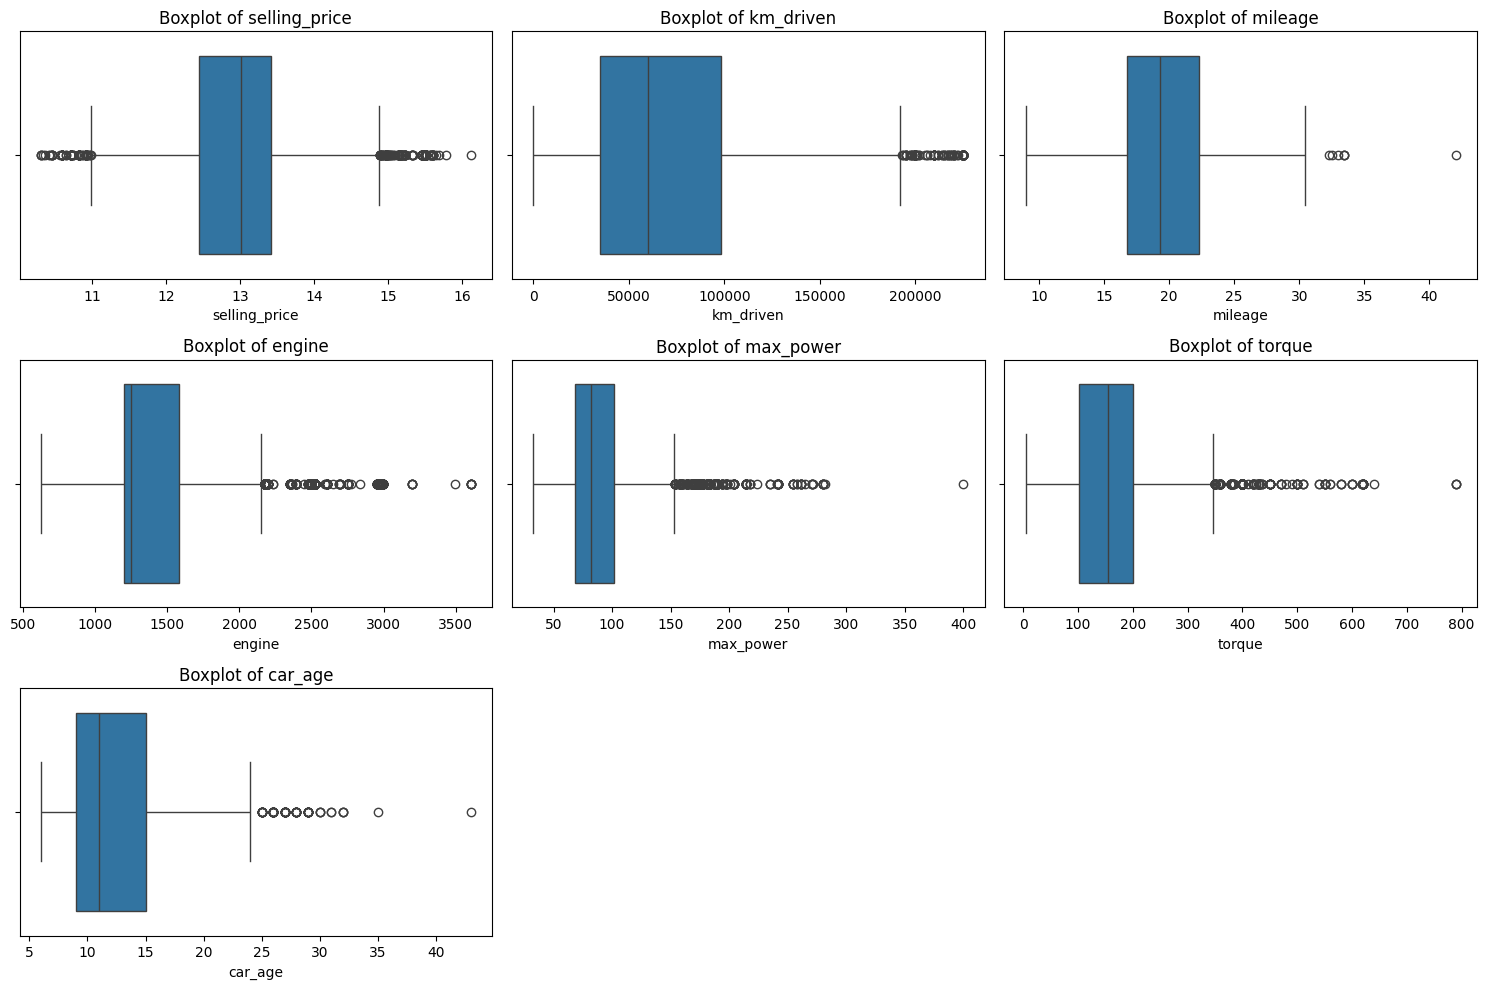

In [1364]:
num_cols = [
    'selling_price',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'torque',
    'car_age'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()



> Removed extreme outliers from the dataset but now outliers still remain



In [1365]:
df = df[df['car_age'] <= 35]

In [1366]:
# iqr_cols = [
#     'km_driven',
# ]

# for col in iqr_cols:

#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)

#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Capping lower outliers
#     df[col] = np.where(
#         df[col] < lower_bound,
#         lower_bound,
#         df[col]
#     )

#     # Capping upper outliers
#     df[col] = np.where(
#         df[col] > upper_bound,
#         upper_bound,
#         df[col]
#     )

# print("IQR capping completed.")

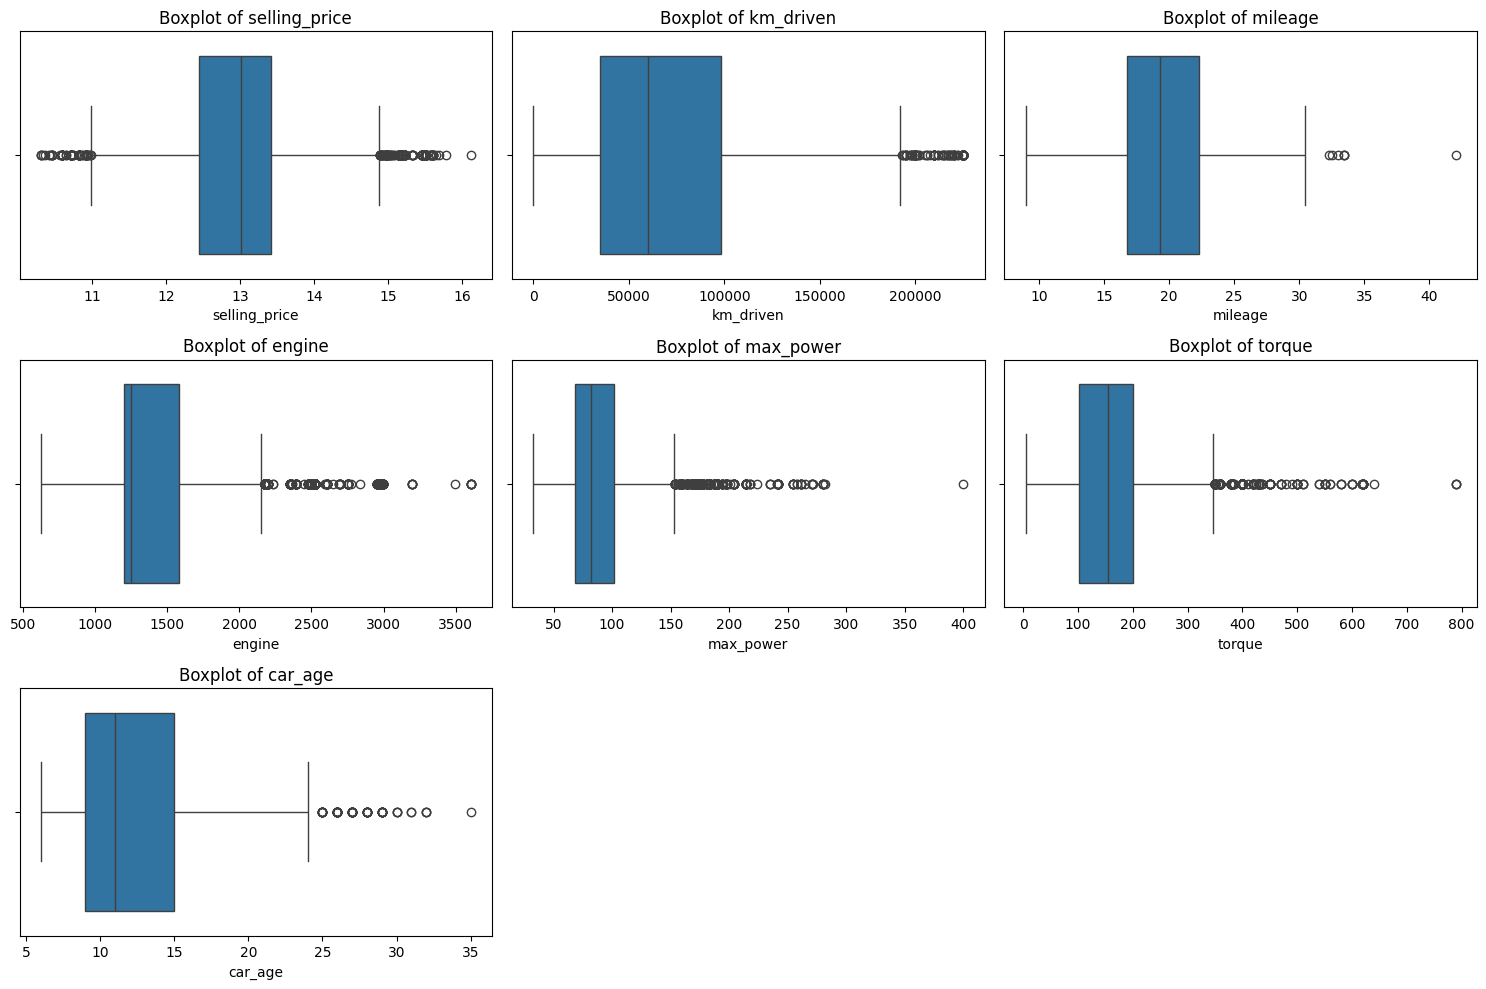

In [1367]:
num_cols = [
    'selling_price',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'torque',
    'car_age'
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):

    plt.subplot(3,3,i)

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

| Column        | Handling               |
| ------------- | ---------------------- |
| selling_price | log1p                  |
| max_power     | log1p  [removed]                |
| torque        | log1p  [removed]                |
| km_driven     | quantile + IQR capping |
| mileage       | IQR capping [removed]           |
| engine        | quantile + IQR capping[removed] |
| car_age       | IQR capping  [kept](<35)          |


> Outliers are handled like this, keeping log transforms as it is and IQR capping or IQR+quantile capping on others


> Applied IQR+Quantile on cols having extreme outliers




> During evaluation/prediction, execute these code so it doesnt stay in log values




> pred_original = np.expm1(predictions)
y_test_original = np.expm1(y_test)




# EDA PROCESS IS DONE
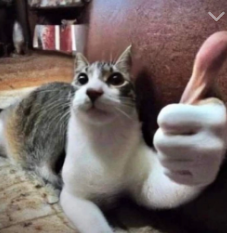

# **ENCODING**

In [1368]:
cat_cols = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

In [1369]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [1370]:
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_mapping)

In [1371]:
df = pd.get_dummies(
    df,
    columns=['fuel','transmission','seller_type'],
    drop_first=True
)

In [1372]:
brand_freq= df['brand'].value_counts()

df['brand'] = df['brand'].map(brand_freq)

In [1373]:
# df = pd.get_dummies(
#     df,
#     columns=['brand'],
#     drop_first=True
# )

In [1374]:
df.head()

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,brand,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,transmission_Manual,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti Swift Dzire VDI,2014,13.017005,145500.0,1,23.40,1248.0,74.00,190.0,5.0,2448,12,True,False,False,True,True,False
1,Skoda Rapid 1.5 TDI Ambition,2014,12.821261,120000.0,2,21.14,1498.0,103.52,250.0,5.0,105,12,True,False,False,True,True,False
2,Honda City 2017-2020 EXi,2006,11.970357,140000.0,3,17.70,1497.0,78.00,12.7,5.0,467,20,False,False,True,True,True,False
3,Hyundai i20 Sportz Diesel,2010,12.323860,127000.0,1,23.00,1396.0,90.00,22.4,5.0,1415,16,True,False,False,True,True,False
4,Maruti Swift VXI BSIII,2007,11.775297,120000.0,1,16.10,1298.0,88.20,11.5,5.0,2448,19,False,False,True,True,True,False


In [1375]:
df.drop(columns=['name'],inplace=True)

In [1376]:
df.head()

,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,brand,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,transmission_Manual,seller_type_Individual,seller_type_Trustmark Dealer
0,2014,13.017005,145500.0,1,23.40,1248.0,74.00,190.0,5.0,2448,12,True,False,False,True,True,False
1,2014,12.821261,120000.0,2,21.14,1498.0,103.52,250.0,5.0,105,12,True,False,False,True,True,False
2,2006,11.970357,140000.0,3,17.70,1497.0,78.00,12.7,5.0,467,20,False,False,True,True,True,False
3,2010,12.323860,127000.0,1,23.00,1396.0,90.00,22.4,5.0,1415,16,True,False,False,True,True,False
4,2007,11.775297,120000.0,1,16.10,1298.0,88.20,11.5,5.0,2448,19,False,False,True,True,True,False


In [1377]:
df.dtypes

,0
year,int64
selling_price,float64
km_driven,float64
owner,int64
mileage,float64
engine,float64
max_power,float64
torque,float64
seats,float64
brand,int64


In [1378]:
df.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
owner,0
mileage,0
engine,0
max_power,0
torque,0
seats,0
brand,0


TESTING THIS AFTER

In [1379]:
df['km_per_year'] = df['km_driven'] / df['car_age']

In [1380]:
df['km_per_year'] = df['km_per_year'].replace(
    [np.inf, -np.inf],
    0
)

# ENCODING DONE
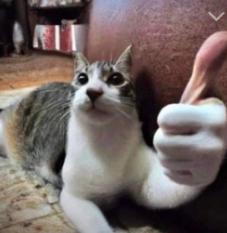

In [1381]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [1382]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [1383]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [1384]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(6501, 17)
(1626, 17)


# **TRAIN TEST SPLIT AND SCALING DONE**
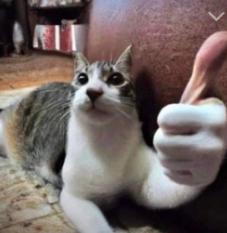

In [1385]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [1386]:
y_pred_log = lr.predict(X_test_scaled)

In [1387]:
y_test_actual = np.expm1(y_test)

y_pred_actual = np.expm1(y_pred_log)

In [1388]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

mse = mean_squared_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 150360.67914521825
RMSE: 337434.8125395303
R2 Score: 0.8346225928721425


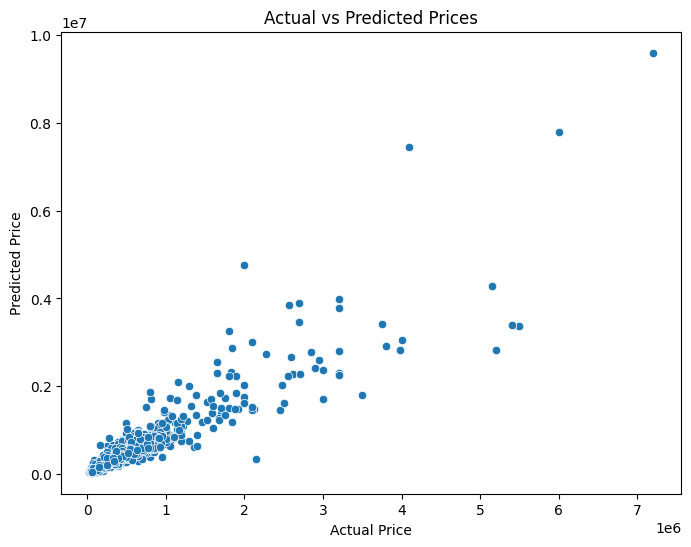

In [1389]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test_actual,
    y=y_pred_actual
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [1390]:
# residuals = y_test_actual - y_pred_actual

# plt.figure(figsize=(8,6))

# sns.scatterplot(
#     x=y_pred_actual,
#     y=residuals
# )

# plt.axhline(0, linestyle='--')

# plt.xlabel("Predicted Price")
# plt.ylabel("Residuals")
# plt.title("Residual Plot")

# plt.show()

In [1391]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)

In [1392]:
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [1393]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

print("R2 :", r2_score(y_test_actual, y_pred_actual))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(
        y_test_actual,
        y_pred_actual
    ))
)

print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))


R2 : 0.9737386195211647
RMSE: 134465.40757930055
MAE : 65782.43245714203


In [1394]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.94619635 0.93779229 0.93641848 0.93796749 0.93300219]
0.9382753586548


In [1395]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_log = xgb.predict(X_test)

y_pred_actual = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

In [1396]:
print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(
        y_test_actual,
        y_pred_actual
    ))
)

print(
    "R2:",
    r2_score(
        y_test_actual,
        y_pred_actual
    )
)

MAE : 68379.6050915783
RMSE: 138645.16268354113
R2: 0.9720806148394312


In [1397]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=200,
                          random_state=42)

In [1398]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [1399]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# =====================================================
# Predictions
# =====================================================

dt_pred_log = dt.predict(X_test)

gbr_pred_log = gbr.predict(X_test)

# =====================================================
# Convert back from log scale
# =====================================================

y_test_actual = np.expm1(y_test)

dt_pred_actual = np.expm1(dt_pred_log)

gbr_pred_actual = np.expm1(gbr_pred_log)

# =====================================================
# Decision Tree Metrics
# =====================================================

dt_mae = mean_absolute_error(
    y_test_actual,
    dt_pred_actual
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        dt_pred_actual
    )
)

dt_r2 = r2_score(
    y_test_actual,
    dt_pred_actual
)

# =====================================================
# Gradient Boosting Metrics
# =====================================================

gbr_mae = mean_absolute_error(
    y_test_actual,
    gbr_pred_actual
)

gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gbr_pred_actual
    )
)

gbr_r2 = r2_score(
    y_test_actual,
    gbr_pred_actual
)

# =====================================================
# Print Results
# =====================================================

print("Decision Tree Regressor")
print("-" * 35)

print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

print("\n")

print("Gradient Boosting Regressor")
print("-" * 35)

print("MAE :", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2 Score:", gbr_r2)

Decision Tree Regressor
-----------------------------------
MAE : 82981.75006855506
RMSE: 167455.63081092684
R2 Score: 0.9592717342473635


Gradient Boosting Regressor
-----------------------------------
MAE : 77865.60409970646
RMSE: 151177.91456742721
R2 Score: 0.9668049668288748


In [1400]:
df.shape

(8127, 18)

## Model Performance Comparison

> Several regression models were trained and evaluated to predict the selling price of used cars. The models were compared using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² Score.

### Linear Regression

> Linear Regression achieved an R² score of **0.83**, indicating that it was able to explain a good portion of the variance in car prices. However, its MAE and RMSE values were relatively high, showing that the model struggled to capture the complex nonlinear relationships present in the dataset.

### Decision Tree Regressor

> The Decision Tree Regressor performed significantly better than Linear Regression, achieving an R² score of **0.959**. The model was able to capture nonlinear relationships effectively, leading to a substantial reduction in prediction error.

### Gradient Boosting Regressor

> Gradient Boosting further improved the performance with an R² score of **0.967** and lower MAE and RMSE values. The boosting technique helped improve prediction accuracy by combining multiple weak learners.

### XGBoost Regressor

> XGBoost achieved excellent performance with an R² score of **0.972** and very low prediction errors. It handled feature interactions and nonlinear patterns efficiently, making it one of the strongest models in this project.

### Random Forest Regressor

> Random Forest produced the best overall performance with an R² score of **0.974**, along with the lowest MAE and RMSE values among all models. Cross-validation also produced consistent scores around **0.938**, indicating that the model generalized well and did not significantly overfit the training data.

## Best Model

> Among all the models tested, the **Random Forest Regressor** performed the best overall due to:
>
> * highest R² Score
> * lowest MAE
> * lowest RMSE
> * stable cross-validation performance
>
> Therefore, Random Forest was selected as the final model for used car price prediction.

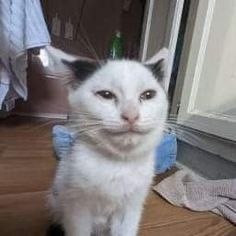